In [ ]:
pip install pandas

You should consider upgrading via the '/Users/malek/End-to-end-MLOps/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [17]:
import pandas as pd

accident = pd.read_csv('accident.csv')

# Keep only the first 30000 rows
accident = accident.head(30000)

# (optionnel) sauvegarder le nouveau dataset
accident.to_csv('accident.csv', index=False)

In [18]:
print(accident.shape)


(30000, 46)


In [19]:
accident.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,30000.000000,30000.000000,30000.000000,0.0,0.0,30000.000000,29740.000000,2236.000000,29574.000000,29849.000000,29736.000000,24335.000000,2731.000000
mean,2.383167,37.991270,-120.922983,NaN,NaN,0.015553,61.911096,35.417397,64.561879,30.002378,9.209214,8.631144,0.029865
std,0.490195,0.632608,5.917090,NaN,NaN,0.279589,13.876696,9.081556,22.592214,0.218530,2.225485,4.618640,0.053157
min,1.000000,36.352592,-123.813927,NaN,NaN,0.000000,3.900000,-8.400000,4.000000,3.010000,0.100000,1.200000,0.000000
25%,2.000000,37.568157,-122.198219,NaN,NaN,0.000000,53.100000,32.700000,49.000000,29.910000,10.000000,5.800000,0.000000
50%,2.000000,37.874857,-121.922119,NaN,NaN,0.010000,61.000000,38.000000,67.000000,30.000000,10.000000,8.100000,0.010000
75%,3.000000,38.496109,-121.415482,NaN,NaN,0.010000,70.000000,41.400000,83.000000,30.100000,10.000000,11.500000,0.040000
max,4.000000,41.428753,-81.550728,NaN,NaN,24.040000,106.000000,66.000000,100.000000,33.040000,80.000000,142.700000,0.550000


In [20]:
pip install folium

You should consider upgrading via the '/Users/malek/End-to-end-MLOps/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [21]:
pip install matplotlib seaborn


You should consider upgrading via the '/Users/malek/End-to-end-MLOps/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [22]:
import warnings
import folium
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
#Ignore the import and install warnings
warnings.filterwarnings("ignore")

/Users/malek/End-to-end-MLOps/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [23]:
pip install sklearn

You should consider upgrading via the '/Users/malek/End-to-end-MLOps/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [37]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score

# 1. Charger les données



# Définir les features et la target
X = accident[['Start_Lat', 'Start_Lng', 'Distance(mi)',
          'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)',
          'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)']]
y = (accident['Severity'] >= 3).astype(int)  # Cible binaire (e.g., accidents graves)

# Diviser les données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Construire le modèle
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Entraîner le modèle
pipeline.fit(X_train, y_train)

# 4. Évaluer le modèle
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("AUC-ROC Score:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.91      0.89      0.90      3719
           1       0.82      0.86      0.84      2281

    accuracy                           0.88      6000
   macro avg       0.87      0.87      0.87      6000
weighted avg       0.88      0.88      0.88      6000

AUC-ROC Score: 0.9406711439143449



===== Random Forest =====
              precision    recall  f1-score   support

           0       0.92      0.90      0.91      3693
           1       0.84      0.87      0.85      2307

    accuracy                           0.89      6000
   macro avg       0.88      0.88      0.88      6000
weighted avg       0.89      0.89      0.89      6000

AUC-ROC: 0.9474417151393274

===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.62      0.99      0.76      3693
           1       0.44      0.02      0.03      2307

    accuracy                           0.61      6000
   macro avg       0.53      0.50      0.39      6000
weighted avg       0.55      0.61      0.48      6000

AUC-ROC: 0.565119450087215

===== Decision Tree =====
              precision    recall  f1-score   support

           0       0.92      0.91      0.91      3693
           1       0.86      0.87      0.86      2307

    accuracy                           0

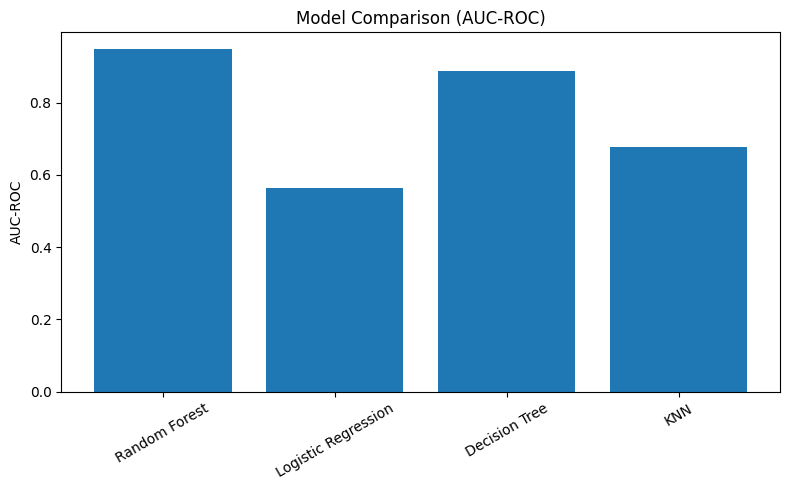

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Load data
accident = pd.read_csv("accident.csv")

# Features and target
X = accident[['Start_Lat', 'Start_Lng', 'Distance(mi)',
              'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)',
              'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)']]

y = (accident['Severity'] >= 3).astype(int)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred))
    print("AUC-ROC:", roc_auc_score(y_test, y_proba))

    results[name] = roc_auc_score(y_test, y_proba)

# Plot
plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values())
plt.title("Model Comparison (AUC-ROC)")
plt.ylabel("AUC-ROC")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

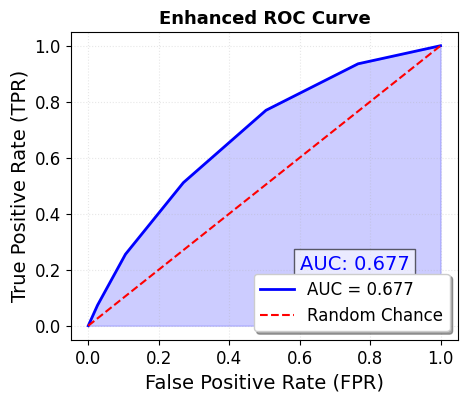

In [48]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

# Generate the ROC curve data
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Enhanced plotting
plt.figure(figsize=(5, 4))  # Larger figure size for clarity
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}", color='blue', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Chance', linewidth=1.5)

# Customizing axes and labels
plt.xlabel("False Positive Rate (FPR)", fontsize=14)
plt.ylabel("True Positive Rate (TPR)", fontsize=14)
plt.title("Enhanced ROC Curve", fontsize=13, fontweight='bold')

# Adding grid, legend, and annotations
plt.grid(alpha=0.3, linestyle=':')
plt.legend(fontsize=12, loc="lower right", frameon=True, fancybox=True, shadow=True)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Highlight the AUC value
plt.text(0.6, 0.2, f"AUC: {roc_auc_score(y_test, y_proba):.3f}", fontsize=14,
         bbox=dict(facecolor='white', alpha=0.6), color='blue')

# Add color fill between the curve and random chance line
plt.fill_between(fpr, tpr, alpha=0.2, color='blue')

# Show the plot
plt.show()


In [52]:
import folium
import pandas as pd

state_geo = 'us-states.json'
state_data = accident

# Initialize the map
US_state_map = folium.Map(location=[37, -102], zoom_start=5)


folium.Choropleth(
    geo_data=state_geo,
    data=state_data,
    columns=['State', 'Severity'],
    key_on='feature.id',
    fill_color='YlGn',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Accident Severity'
).add_to(US_state_map)

# Add layer control to toggle choropleth layers
folium.LayerControl().add_to(US_state_map)

# Display the map
US_state_map.save("map.html")


In [40]:
import joblib

joblib.dump(pipeline, 'accident_prediction_model.pkl')

print("Model saved successfully!")


Model saved successfully!


In [41]:
# Load the saved model
loaded_pipeline = joblib.load('accident_prediction_model.pkl')

y_pred_loaded = loaded_pipeline.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_loaded))


              precision    recall  f1-score   support

           0       0.91      0.89      0.90      3719
           1       0.82      0.86      0.84      2281

    accuracy                           0.88      6000
   macro avg       0.87      0.87      0.87      6000
weighted avg       0.88      0.88      0.88      6000



**BERT**

In [46]:
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader, Dataset
import torch
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from torch.optim import AdamW
from tqdm import tqdm

# Charger les données
file_path = "accident.csv"
data = pd.read_csv(file_path)

# Nettoyage basique
data = data[['Description', 'Severity']].dropna()

# Limiter à un sous-échantillon (ajustez selon vos ressources)
data = data.sample(n=30000, random_state=42)

# Convertir les étiquettes en binaire
# Classe 0 pour gravité faible (<2), Classe 1 pour gravité élevée (>=2)
data['Severity'] = data['Severity'].apply(lambda x: 0 if x < 3 else 1)

# Vérifier la distribution des classes
print(data['Severity'].value_counts())

# 2. Préparation des données
class AccidentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(
            text, truncation=True, padding='max_length', max_length=self.max_length, return_tensors="pt"
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.long)
        }

# Tokenizer BERT
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Séparer les ensembles
train_texts, val_texts, train_labels, val_labels = train_test_split(
    data['Description'], data['Severity'], test_size=0.2, random_state=42
)

train_dataset = AccidentDataset(train_texts.tolist(), train_labels.tolist(), tokenizer, max_length=128)
val_dataset = AccidentDataset(val_texts.tolist(), val_labels.tolist(), tokenizer, max_length=128)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

# 3. Charger le modèle pour classification binaire
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# 4. Entraîner le modèle
optimizer = AdamW(model.parameters(), lr=5e-5)

for epoch in range(2):  # Nombre d'époques
    model.train()
    loop = tqdm(train_loader, leave=True)
    for batch in loop:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        loop.set_description(f'Epoch {epoch}')
        loop.set_postfix(loss=loss.item())

# 5. Évaluer le modèle
model.eval()
predictions, true_labels = [], []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        predictions.extend(torch.argmax(logits, dim=-1).cpu().numpy())
        true_labels.extend(batch['label'].numpy())

# Vérifier les classes présentes
print("Classes dans true_labels :", set(true_labels))
print("Classes dans predictions :", set(predictions))

# Générer le rapport de classification pour les deux classes
print(classification_report(
    true_labels,
    predictions,
    target_names=['Low Severity', 'High Severity'],  # Noms des classes
    labels=[0, 1]  # Classes binaires
))


Severity
0    18466
1    11534
Name: count, dtype: int64


ImportError: 
BertForSequenceClassification requires the PyTorch library but it was not found in your environment. Check out the instructions on the
installation page: https://pytorch.org/get-started/locally/ and follow the ones that match your environment.
Please note that you may need to restart your runtime after installation.


In [45]:
pip install torch 

     |████████████████████████████████| 73.6 MB 3.7 MB/s eta 0:00:011
     |████████████████████████████████| 6.3 MB 4.6 MB/s eta 0:00:01
     |████████████████████████████████| 536 kB 4.3 MB/s eta 0:00:01
You should consider upgrading via the '/Users/malek/End-to-end-MLOps/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Convert predictions and true_labels to tensors for computation
predictions_tensor = torch.tensor(predictions)
true_labels_tensor = torch.tensor(true_labels)

# Compute accuracy
accuracy = (predictions_tensor == true_labels_tensor).sum().item() / len(true_labels)
print(f"Accuracy: {accuracy * 100:.2f}%")


Accuracy: 97.48%


In [ ]:
import torch

# Save the model's weights (state_dict)
torch.save(model.state_dict(), "bert_accident_severity_model.pth")
print("Model weights saved as 'bert_accident_severity_model.pth'")


Model weights saved as 'bert_accident_severity_model.pth'


In [ ]:
from transformers import BertForSequenceClassification

# Step 1: Reinitialize the model architecture
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

# Step 2: Load the saved weights into the model
model.load_state_dict(torch.load("bert_accident_severity_model.pth"))

# Step 3: Ensure the model is in evaluation mode (important for inference)
model.eval()

print("Model reinitialized and weights loaded successfully!")


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model reinitialized and weights loaded successfully!


**Predicting using LLMs**

In [ ]:
def predict_severity(description, model, tokenizer, device, max_length=128):
    # Ensure the model is on the correct device
    model.to(device)

    # Preprocess the input description
    encoding = tokenizer(
        description,
        truncation=True,
        padding='max_length',
        max_length=max_length,
        return_tensors="pt"
    )

    # Move input tensors to the same device as the model
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    # Set the model to evaluation mode
    model.eval()

    with torch.no_grad():
        # Forward pass
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

    # Get the predicted class
    predicted_class = torch.argmax(logits, dim=-1).item()

    return "Low Severity" if predicted_class == 0 else "High Severity"


In [ ]:
# Move model to the correct device
model.to(device)

# Example description
new_description = "The car skid off the road and hit a tree, causing minor injuries to the driver."

# Make a prediction
severity = predict_severity(new_description, model, tokenizer, device)
print(f"Predicted severity for the description: {severity}")


Predicted severity for the description: Low Severity


In [ ]:
# **Prediction for new data**
new_data = pd.DataFrame({
    'Start_Lat': [34.0522],
    'Start_Lng': [-118.2437],
    'Distance(mi)': [0.5],
    'Temperature(F)': [75.0],
    'Wind_Chill(F)': [75.0],
    'Humidity(%)': [60],
    'Pressure(in)': [30.0],
    'Visibility(mi)': [10.0],
    'Wind_Speed(mph)': [5.0],
    'Precipitation(in)': [0.0]
})

# Predict severity
predicted_class = pipeline.predict(new_data)
predicted_proba = pipeline.predict_proba(new_data)[:, 1]

print(f"Predicted class: {'Severe' if predicted_class[0] == 1 else 'Non-Severe'}")
print(f"Predicted probability of severe accident: {predicted_proba[0]:.2f}")

Predicted class: Severe
Predicted probability of severe accident: 0.53


**Definig Default vaues**

In [ ]:
# Define default values for missing features
default_values = {
    'Start_Lat': 34.0522,  # Default latitude
    'Start_Lng': -118.2437,  # Default longitude
    'Distance(mi)': 0.5,
    'Temperature(F)': 75.0,
    'Wind_Chill(F)': 75.0,
    'Humidity(%)': 60,
    'Pressure(in)': 30.0,
    'Visibility(mi)': 10.0,
    'Wind_Speed(mph)': 5.0,
    'Precipitation(in)': 0.0
}

# Provide partial input and fill missing features with defaults
partial_data = {
    'Start_Lat': 37.7749,  # User-provided
    'Start_Lng': -122.4194  # User-provided
}
complete_data = {**default_values, **partial_data}

# Convert to DataFrame for prediction
new_data = pd.DataFrame([complete_data])

# Predict severity
predicted_class = pipeline.predict(new_data)
predicted_proba = pipeline.predict_proba(new_data)[:, 1]

print(f"Predicted class: {'Severe' if predicted_class[0] == 1 else 'Non-Severe'}")
print(f"Predicted probability of severe accident: {predicted_proba[0]:.2f}")


Predicted class: Non-Severe
Predicted probability of severe accident: 0.49


Combined BERT+ RandomForest

In [ ]:
import numpy as np

def predict_combined(description, numerical_features, bert_model, bert_tokenizer, rf_pipeline, device):
    # Predict with BERT
    bert_model.eval()
    encoding = bert_tokenizer(
        description,
        truncation=True,
        padding='max_length',
        max_length=128,
        return_tensors="pt"
    )
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        bert_output = bert_model(input_ids, attention_mask=attention_mask)
        bert_prob = torch.softmax(bert_output.logits, dim=-1).cpu().numpy()[0][1]  # Probability of class 1 (high severity)

    # Predict with Random Forest
    numerical_features = np.array(numerical_features).reshape(1, -1)  # Ensure correct shape
    rf_prob = rf_pipeline.predict_proba(numerical_features)[:, 1][0]  # Probability of class 1 (high severity)

    # Combine probabilities (weighted average or simple average)
    combined_prob = (bert_prob + rf_prob) / 2  # Adjust weights if necessary
    final_prediction = 1 if combined_prob >= 0.5 else 0  # Threshold for severity

    return {
        "BERT Probability": bert_prob,
        "Random Forest Probability": rf_prob,
        "Combined Probability": combined_prob,
        "Final Prediction": "High Severity" if final_prediction == 1 else "Low Severity"
    }


In [ ]:
# Example inputs
description = "The car crashed into the barrier, causing significant damage."
numerical_features = [34.0522, -118.2437, 0.5, 75.0, 75.0, 60, 30.0, 10.0, 5.0, 0.0]  # Example numerical data

# Load trained BERT and Random Forest models
# Assuming BERT is on `bert_model` and Random Forest pipeline on `rf_pipeline`
result = predict_combined(
    description=description,
    numerical_features=numerical_features,
    bert_model=model,  # Replace `model` with your loaded BERT model
    bert_tokenizer=tokenizer,
    rf_pipeline=pipeline,  # Replace `pipeline` with your Random Forest pipeline
    device=device
)

# Print results
print(result)


{'BERT Probability': 0.07172849, 'Random Forest Probability': 0.53, 'Combined Probability': 0.300864245146513, 'Final Prediction': 'Low Severity'}


In [ ]:
!pip install ipywidgets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 48.6 MB/s eta 0:00:00


In [ ]:
import torch
import numpy as np
from transformers import BertTokenizer, BertForSequenceClassification
import joblib
import ipywidgets as widgets
from ipywidgets import interact
from IPython.display import display

# Load pre-trained models
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load BERT model and tokenizer
bert_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model.to(device)

# Load Random Forest model (assuming it's saved as a .pkl or .joblib file)
rf_pipeline = joblib.load("accident_prediction_model.pkl")  # Adjust path to the saved model

# Define the combined prediction function
def predict_combined(description, numerical_features, bert_model, bert_tokenizer, rf_pipeline, device):
    # Predict with BERT
    bert_model.eval()
    encoding = bert_tokenizer(
        description,
        truncation=True,
        padding='max_length',
        max_length=128,
        return_tensors="pt"
    )
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        bert_output = bert_model(input_ids, attention_mask=attention_mask)
        bert_prob = torch.softmax(bert_output.logits, dim=-1).cpu().numpy()[0][1]  # Probability of class 1 (high severity)

    # Predict with Random Forest
    numerical_features = np.array(numerical_features).reshape(1, -1)  # Ensure correct shape
    rf_prob = rf_pipeline.predict_proba(numerical_features)[:, 1][0]  # Probability of class 1 (high severity)

    # Combine probabilities (simple average)
    combined_prob = (bert_prob + rf_prob) / 2
    final_prediction = 1 if combined_prob >= 0.5 else 0  # Threshold for severity

    return {
        "BERT Probability": bert_prob,
        "Random Forest Probability": rf_prob,
        "Combined Probability": combined_prob,
        "Final Prediction": "High Severity" if final_prediction == 1 else "Low Severity"
    }


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Create widgets for user input

description_widget = widgets.Textarea(
    value='',
    placeholder='Enter accident description here...',
    description='Description:',
    disabled=False,
    layout=widgets.Layout(width='80%', height='150px')
)

start_lat_widget = widgets.FloatText(
    value=0.0,
    description='Start Lat:',
    disabled=False
)

start_lng_widget = widgets.FloatText(
    value=0.0,
    description='Start Lng:',
    disabled=False
)

distance_widget = widgets.FloatText(
    value=0.0,
    description='Distance (mi):',
    disabled=False
)

temperature_widget = widgets.FloatText(
    value=0.0,
    description='Temperature (°F):',
    disabled=False
)

wind_chill_widget = widgets.FloatText(
    value=0.0,
    description='Wind Chill (°F):',
    disabled=False
)

humidity_widget = widgets.FloatText(
    value=0.0,
    description='Humidity (%):',
    disabled=False
)

pressure_widget = widgets.FloatText(
    value=0.0,
    description='Pressure (in):',
    disabled=False
)

visibility_widget = widgets.FloatText(
    value=0.0,
    description='Visibility (mi):',
    disabled=False
)

wind_speed_widget = widgets.FloatText(
    value=0.0,
    description='Wind Speed (mph):',
    disabled=False
)

precipitation_widget = widgets.FloatText(
    value=0.0,
    description='Precipitation (in):',
    disabled=False
)

# Create a button to trigger prediction
predict_button = widgets.Button(description="Predict Severity")

# Output area to display results
output = widgets.Output()
display(description_widget, start_lat_widget, start_lng_widget, distance_widget,
        temperature_widget, wind_chill_widget, humidity_widget, pressure_widget,
        visibility_widget, wind_speed_widget, precipitation_widget, predict_button, output)


Textarea(value='', description='Description:', layout=Layout(height='150px', width='80%'), placeholder='Enter …

FloatText(value=0.0, description='Start Lat:')

FloatText(value=0.0, description='Start Lng:')

FloatText(value=0.0, description='Distance (mi):')

FloatText(value=0.0, description='Temperature (°F):')

...

FloatText(value=0.0, description='Visibility (mi):')

FloatText(value=0.0, description='Wind Speed (mph):')

FloatText(value=0.0, description='Precipitation (in):')

Button(description='Predict Severity', style=ButtonStyle())

Output()